In [2]:
# Module imports

from sqlalchemy.engine.base import Engine


import matplotlib.pyplot as plt
import pandas as pd
from sqlalchemy import func
from sqlmodel import Session, select
from usigrabber.db import load_db_engine
from usigrabber.db.schema import (
    Modification,
    ModifiedPeptide,
    CvParam,
    MzidFile,
    PeptideEvidence,
    PeptideSpectrumMatch,
    Project,
    ProjectCountry,
    ProjectKeyword,
    ProjectTag,
    PSMPeptideEvidence,
    Reference,
)

from pronto.ontology import Ontology
import json
from pathlib import Path
from usigrabber.utils import get_cache_dir
import ijson

engine: Engine = load_db_engine()

2025-12-15 10:30:00.777 | usigrabber.db.engine | INFO | Using PostgreSQL database at mpws2025br1.cloud.sci.hpi.de [engine.py:49]


In [3]:
# Parse all_projects.json to get unique instruments, organisms, diseases
all_projects_path = get_cache_dir() / "pride" / "all_projects.json"
unique_elements_path = Path("unique_elements.json")
def parse_all_items() -> None:
    instruments = set()
    organisms = set()
    diseases = set()

    for item in ijson.items(open(all_projects_path), "item"):
        instruments_item = item.get("instruments", [])
        for instr in instruments_item:
            accession = instr.get("accession")
            if not accession:
                print(f"Missing accession in instrument: {instr}")
            instruments.add(accession)

        organisms_item = item.get("organisms", [])
        for org in organisms_item:
            accession = org.get("accession")
            if not accession:
                print(f"Missing accession in organism: {org}")
            organisms.add(accession.replace("NEWT", "NCBITaxon"))

        diseases_item = item.get("diseases", [])
        for dis in diseases_item:
            accession = dis.get("accession")
            if not accession:
                print(f"Missing accession in disease: {dis}")
            diseases.add(accession)

    unique_elements = {
        "instruments": list(instruments),
        "organisms": list(organisms),
        "diseases": list(diseases),
    }
    with open(unique_elements_path, "w") as f:
        json.dump(unique_elements, f, indent=2)

# parse_all_items()

with open(unique_elements_path) as f:
    unique_elements: dict[str, list[str]] = json.load(f)

In [4]:
print(f"Number of unique instruments: {len(unique_elements['instruments'])}")
print(f"Number of unique organisms: {len(unique_elements['organisms'])}")
print(f"Number of unique diseases: {len(unique_elements['diseases'])}")

Number of unique instruments: 243
Number of unique organisms: 4337
Number of unique diseases: 1248


In [5]:
unique_elements['organisms'][:10]

['NCBITaxon:1028563',
 'NCBITaxon:419610',
 'NCBITaxon:959',
 'NCBITaxon:5544',
 'NCBITaxon:60162',
 'NCBITaxon:229990',
 'NCBITaxon:1214786',
 'NCBITaxon:37334',
 'NCBITaxon:515622',
 'NCBITaxon:2050920']

In [6]:
organism_usage = pd.read_sql(
    """
    SELECT c.accession, COUNT(DISTINCT pcp.project_accession) AS project_count
    FROM project_cv_params AS pcp
    JOIN cv_params AS c ON c.id = pcp.cv_param_id
    WHERE REPLACE(c.accession, 'NEWT', 'NCBITaxon') = ANY(%(accessions)s)
    GROUP BY c.accession
    """,
    con=engine,
    params={"accessions": unique_elements["organisms"]},
)
organism_usage

,accession,project_count
0,NCBITaxon:10066,6
1,NCBITaxon:10088,4
2,NCBITaxon:10114,2
3,NCBITaxon:1117,1
4,NCBITaxon:1236,3
...,...,...
62,NEWT:85962,1
63,NEWT:884019,1
64,NEWT:9031,1
65,NEWT:931281,1


In [ ]:
ncbitaxon = Ontology.from_obo_library("ncbitaxon.obo")
print(ncbitaxon.path)
def get_organism_name(accession: str) -> str:
    term = ncbitaxon.get(accession)
    if term is not None:
        return term.name or ""
    else:
        return accession
get_organism_name("NCBITaxon:10066")

In [ ]:

top_n = 10
ordered = organism_usage.sort_values("project_count", ascending=False).reset_index(drop=True)
top = ordered.iloc[:top_n].copy()

# for each row in top, lookup the accession to get a more readable name and store as 'label' column
top["accession"] = top["accession"].apply(get_organism_name)

if len(ordered) > top_n:
    other_count = ordered.iloc[top_n:]["project_count"].sum()
    top = pd.concat(
        [top, pd.DataFrame({"accession": ["other"], "project_count": [other_count]})],
        ignore_index=True,
    )

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(
    top["project_count"],
    labels=top["accession"],
    autopct=lambda pct: f"{pct:.1f}% ({int(round(pct / 100 * top['project_count'].sum()))})",
    startangle=90,
)
ax.set_title("Project distribution by organism")
ax.axis("equal")
plt.show()

# General stats

In [5]:
project_count = pd.read_sql(
    """
    SELECT project_count, psm_count
    FROM
        (SELECT COUNT(*) AS project_count FROM projects),
        (SELECT COUNT(*) AS psm_count FROM peptide_spectrum_matches)
    """,
    con=engine,
)
print(f"Number of projects: {project_count['project_count'][0]:,}")
print(f"Number of PSMs: {project_count['psm_count'][0]:,}")

Number of projects: 386
Number of PSMs: 31,124,643


# Instruments

In [6]:
instruments_path = Path("instruments.json")

def get_instruments() -> None:
    instruments = {}
    ms = Ontology.from_obo_library("ms.obo")
    for s in iter(ms["MS:1000031"].subclasses()):
        if not s.is_leaf(): continue
        instruments[s.id] = s.name
    json.dump(instruments, instruments_path.open("w"), indent=2)

# get_instruments()

instruments: dict[str, str] = json.load(instruments_path.open("r"))

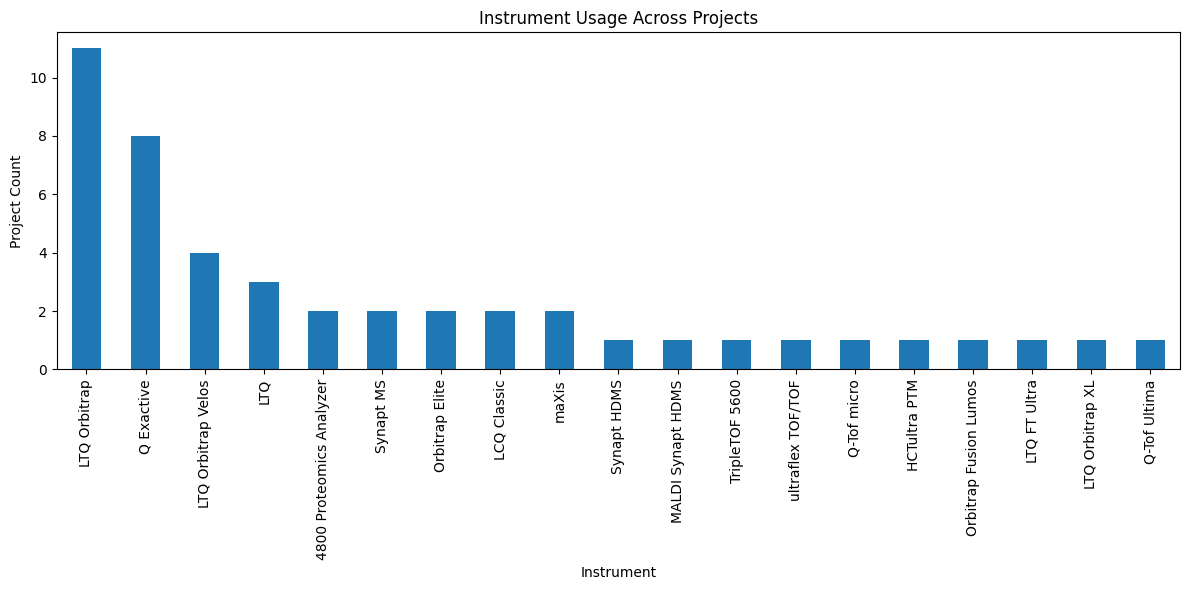

In [7]:
# Instrument usage across projects

instrument_ids = list(instruments.keys())

project_params = pd.read_sql(
    """
    SELECT pcp.project_accession, c.accession
    FROM project_cv_params AS pcp
    JOIN cv_params AS c ON c.id = pcp.cv_param_id
    WHERE c.accession = ANY(%(accessions)s)
    """,
    con=engine,
    params={"accessions": instrument_ids},
)

instrument_usage = (
    project_params
    .assign(instrument=lambda df: df["accession"].map(instruments))
    ["instrument"]
    .value_counts()
    .sort_values(ascending=False)
)

ax = instrument_usage.plot(kind="bar", figsize=(12, 6))
ax.set_title("Instrument Usage Across Projects")
ax.set_xlabel("Instrument")
ax.set_ylabel("Project Count")
plt.tight_layout()
plt.show()

## TODO:
- [ ] Modifications
- [ ] Scores
- [ ] Organisms/Tissues
- [ ] Software